 ☕ Coffee Shop Sales Analysis

This Jupyter Notebook performs data cleaning, exploration, and visualization on a Coffee Shop Sales dataset.

## Objectives:
1. Handle missing values
2. Drop unnecessary columns
3. Use `.info()`, `.describe()`, `.unique()` to understand the dataset
4. Detect and handle outliers
5. Visualize the data using charts and heatmaps

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\DATASETS\Coffee Shop Sales.csv')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 1. Handle Missing Values
*Reason:* Missing data can skew analysis results.
*Action:* We'll check for missing values and fill them appropriately.

In [3]:
# Check for missing values
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [4]:
# Fill missing values
df.fillna(method='ffill', inplace=True)  # Forward fill as a simple strategy
df.isnull().sum()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2560\995660755.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill as a simple strategy


transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

## 2. Drop Unnecessary Columns
*Reason:* Unused or irrelevant columns add clutter.
*Action:* Drop unnamed or index columns if present.

In [43]:
# Drop unnecessary columns
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    df=df.drop(['transaction_id','store_id','product_id'], inplace=True)



In [44]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 3. Dataset Overview
*Reason:* Understand the structure and summary statistics.
*Action:* Use `.info()`, `.describe()`, and `.unique()`.

In [33]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


In [34]:
# Statistical summary
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


In [35]:
# Unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()[:5]}")

transaction_date: ['01-01-2023' '02-01-2023' '03-01-2023' '04-01-2023' '05-01-2023']
transaction_time: ['07:06:11' '07:08:56' '07:14:04' '07:20:24' '07:22:41']
store_location: ['Lower Manhattan' "Hell's Kitchen" 'Astoria']
product_category: ['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours']
product_type: ['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone']
product_detail: ['Ethiopia Rg' 'Spicy Eye Opener Chai Lg' 'Dark chocolate Lg'
 'Our Old Time Diner Blend Sm' 'Oatmeal Scone']


## 4. Outlier Detection
*Reason:* Outliers can skew results.
*Action:* Use boxplots and handle them.

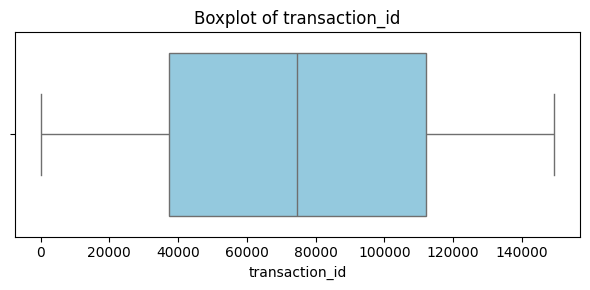

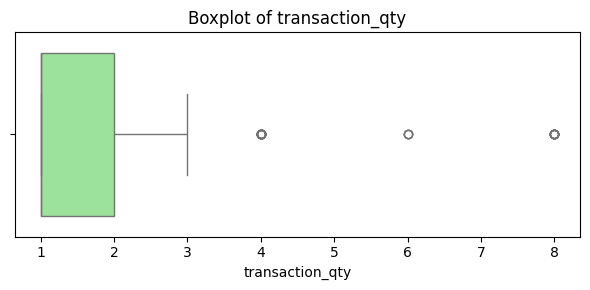

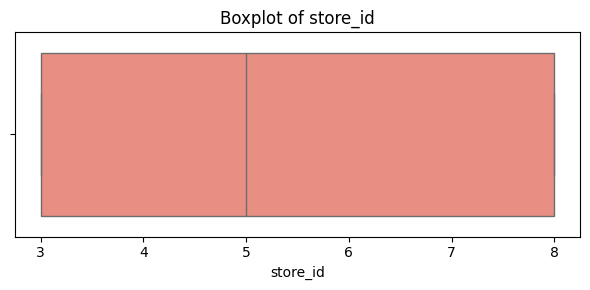

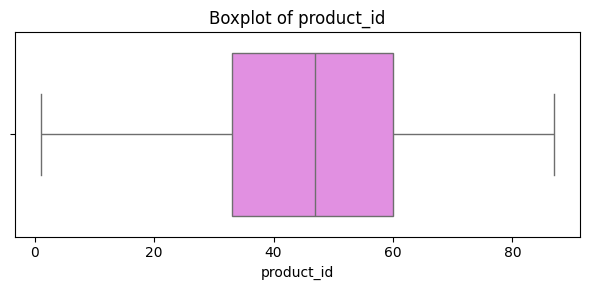

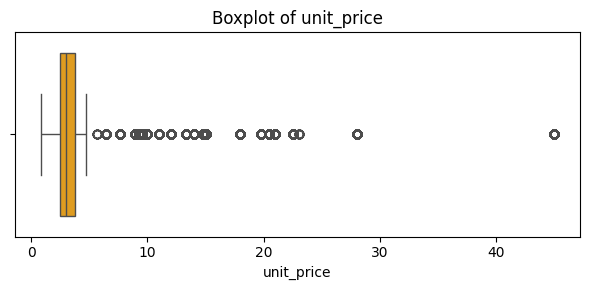

In [36]:
# Boxplot to detect outliers in numeric columns
colors = ['skyblue', 'lightgreen', 'salmon', 'violet', 'orange', 'lightgray', 'gold', 'turquoise']
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Loop through each numeric column and plot with a different color
for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x=col, color=colors[i % len(colors)])  # Cycle through colors
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

# Dictionary to store outliers
outliers = {}

# Loop through each numeric column to detect outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outlier_values = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    # Store results
    if not outlier_values.empty:
        outliers[col] = outlier_values

# Display outliers
for col, values in outliers.items():
    print(f"\nOutliers in '{col}':")
    print(values)


Outliers in 'transaction_qty':
4163      4
4352      4
9310      8
9365      8
16490     4
21416     4
21532     4
38494     4
38550     4
38707     4
38953     4
39176     6
60777     4
61057     4
61317     4
61622     6
68806     8
68981     8
87847     4
87987     4
88557     4
88616     4
94332     4
97979     8
98275     8
122099    4
122390    4
122715    4
122799    4
123153    4
123186    6
129128    4
133186    8
133337    8
133407    8
148702    8
Name: transaction_qty, dtype: int64

Outliers in 'unit_price':
3263       8.95
3293      21.00
3296      28.00
3302      28.00
3408      28.00
          ...  
148927    19.75
148985     8.95
149017     6.40
149064    14.75
149089    18.00
Name: unit_price, Length: 4212, dtype: float64


## 5. Visualization using Charts and Heatmaps
*Reason:* Visualizations help uncover patterns and relationships.
*Action:* Create bar charts, line plots, and heatmaps.

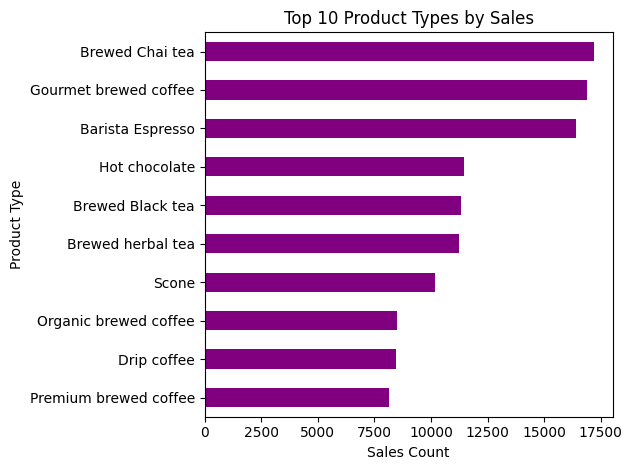

In [20]:
# Sales by Product

top_products = df['product_type'].value_counts().head(10)
top_products.plot(kind='barh', color='purple')
plt.title('Top 10 Product Types by Sales')
plt.xlabel('Sales Count')
plt.ylabel('Product Type')
plt.gca().invert_yaxis()  # Puts the highest value at the top
plt.tight_layout()
plt.show()

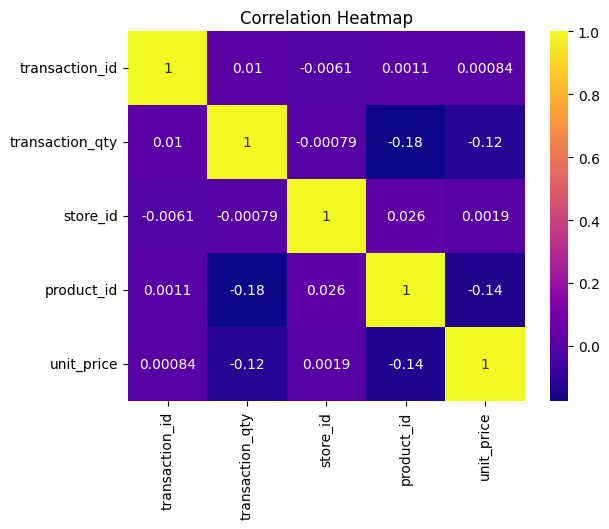

In [24]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()